In [1]:
!pip install mediapipe==0.10.33 -q
print("✅ MediaPipe 0.10.33 installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.9 MB/s eta 0:00:00
✅ MediaPipe 0.10.33 installed!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, "/content/drive/MyDrive/CV_PROJECT")
print("✅ Ready!")

Mounted at /content/drive
✅ Ready!


In [3]:
import os
project_path = "/content/drive/MyDrive/CV_PROJECT"

utils_code = '''# utils.py
# MediaPipe hand detection — compatible with mediapipe 0.10.x
# The new API is slightly more setup but works the same way.

import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

# These are the 21 landmark connections (which dots to connect with lines)
# Copied from MediaPipe documentation — tells us which joints are connected
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),         # thumb
    (0,5),(5,6),(6,7),(7,8),         # index
    (0,9),(9,10),(10,11),(11,12),    # middle
    (0,13),(13,14),(14,15),(15,16),  # ring
    (0,17),(17,18),(18,19),(19,20),  # pinky
    (5,9),(9,13),(13,17)             # palm connections
]


def download_model(save_path):
    """
    Downloads the MediaPipe hand landmark model file.
    Only needs to run once — saves to your Drive.
    """
    import urllib.request
    model_url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"

    print("⬇️ Downloading MediaPipe hand model (~25MB)...")
    urllib.request.urlretrieve(model_url, save_path)
    print(f"✅ Model saved to: {save_path}")


def init_mediapipe(model_path, max_hands=2, detection_conf=0.7, tracking_conf=0.7):
    """
    Sets up the MediaPipe HandLandmarker detector.
    Returns a detector object we reuse for every frame.
    """
    base_options = mp_python.BaseOptions(model_asset_path=model_path)

    options = mp_vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=max_hands,
        min_hand_detection_confidence=detection_conf,
        min_hand_presence_confidence=tracking_conf,
        running_mode=mp_vision.RunningMode.IMAGE  # one frame at a time
    )

    detector = mp_vision.HandLandmarker.create_from_options(options)
    return detector


def detect_hand(frame, detector):
    """
    Runs hand detection on a BGR frame.
    Returns:
      - results         : raw MediaPipe output (has landmark coords)
      - annotated_frame : same frame with dots + lines drawn on it
    """
    # New API needs an mp.Image object, not a raw numpy array
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

    results = detector.detect(mp_image)

    annotated_frame = frame.copy()
    h, w = frame.shape[:2]

    if results.hand_landmarks:
        for hand in results.hand_landmarks:

            # Convert normalized coords (0.0-1.0) to actual pixel positions
            points = []
            for lm in hand:
                px = int(lm.x * w)
                py = int(lm.y * h)
                points.append((px, py))

            # Draw connection lines first (so dots appear on top)
            for start_idx, end_idx in HAND_CONNECTIONS:
                cv2.line(annotated_frame, points[start_idx], points[end_idx],
                         (0, 200, 0), 2)

            # Draw landmark dots
            for i, (px, py) in enumerate(points):
                cv2.circle(annotated_frame, (px, py), 5, (0, 0, 255), -1)

    return results, annotated_frame


def hand_detected(results):
    """Returns True if at least one hand was found."""
    return len(results.hand_landmarks) > 0
'''

with open(os.path.join(project_path, "utils.py"), "w") as f:
    f.write(utils_code)

print("✅ utils.py saved with new API!")

✅ utils.py saved with new API!


In [4]:
import os
import sys
sys.path.insert(0, "/content/drive/MyDrive/CV_PROJECT")
import utils

model_path = "/content/drive/MyDrive/CV_PROJECT/model/hand_landmarker.task"

# Only download if not already there
if not os.path.exists(model_path):
    utils.download_model(model_path)
else:
    print("✅ Model already downloaded!")

✅ Model already downloaded!


🔧 Loading detector...
📸 Hold your hand open in front of the camera...


<IPython.core.display.Javascript object>

✅ Hand detected! 21 landmarks found


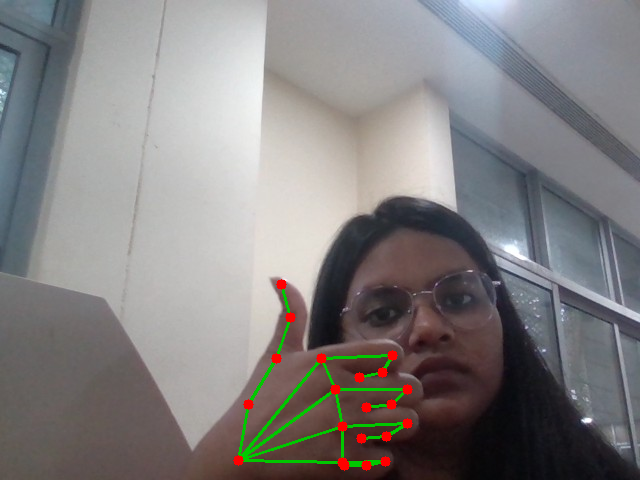

In [6]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from PIL import Image
import io
import config
import utils


def capture_frame_from_colab():
    js_code = Javascript('''
        async function captureFrame() {
            const video = document.createElement('video');
            video.style.display = 'none';
            document.body.appendChild(video);
            const stream = await navigator.mediaDevices.getUserMedia({video: {width:640, height:480}});
            video.srcObject = stream;
            await new Promise(resolve => {
                video.onloadedmetadata = () => video.play().then(resolve);
            });
            await new Promise(resolve => setTimeout(resolve, 1500));
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth || 640;
            canvas.height = video.videoHeight || 480;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());
            video.remove();
            return canvas.toDataURL('image/jpeg', 0.9);
        }
        captureFrame()
            .then(r => element.textContent = r)
            .catch(e => element.textContent = 'ERROR:' + e.message);
    ''')
    display(js_code)
    result = eval_js('captureFrame()', timeout_sec=15)
    image_bytes = b64decode(result.split(',')[1])
    frame = np.array(Image.open(io.BytesIO(image_bytes)))
    return cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)


def show_frame(frame):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(frame_rgb))


# --- Run ---
model_path = "/content/drive/MyDrive/CV_PROJECT/model/hand_landmarker.task"

print("🔧 Loading detector...")
detector = utils.init_mediapipe(
    model_path=model_path,
    max_hands=config.MAX_HANDS,
    detection_conf=config.DETECTION_CONFIDENCE,
    tracking_conf=config.TRACKING_CONFIDENCE
)

print("📸 Hold your hand open in front of the camera...")
frame = capture_frame_from_colab()
frame = cv2.resize(frame, (config.FRAME_WIDTH, config.FRAME_HEIGHT))

results, annotated_frame = utils.detect_hand(frame, detector)

if utils.hand_detected(results):
    count = len(results.hand_landmarks[0])
    print(f"✅ Hand detected! {count} landmarks found")
else:
    print("⚠️ No hand detected — try better lighting or move hand closer")

show_frame(annotated_frame)


In [7]:
# things done in this notebook
# hand model downloaded
# utils.py with detection functions
# 21 landmarks detected correctly
# red dots + green lines on hand